## This script is designed to get minite-wise sentiment analysis

In [57]:
from IPython.core.display import HTML
import requests
import time
import pandas as pd
import numpy as np
HTML("""
<style>
.container { width:100% !important; }
</style>
""")
import matplotlib.pyplot as plt

In [2]:
api_key = "IZ2AFNDJHMO5AV1O" # Free API key for Alpha Vantage

## News sentiment analysis

In [3]:
def _get_data(symbols,time_from,time_to,api_key):
    url = f"https://www.alphavantage.co/query?function=NEWS_SENTIMENT&tickers={symbols}&time_from={time_from}&time_to={time_to}&limit=1000&apikey={api_key}"
    r = requests.get(url)
    data = r.json()
    return data

def _get_label_sentiment(x):
    if x <= -0.35:
        return 'Bearish','Bearish'
    elif -0.35 < x <= -0.15:
        return 'Somewhat-Bearish','Bearish'
    elif -0.15 < x < 0.15:
        return 'Neutral','Neutral'
    elif 0.15 <= x < 0.35:
        return 'Somewhat_Bullish','Bullish'
    else:  # x >= 0.35
        return 'Bullish','Bullish'

In [4]:
def get_dataset(ticker='AAPL',
                filter_str="aapl|appel",
                time_from="20230410T0130",
                time_to='20240920T2000',
                MAX_API_CALLS_PER_DAY = 25, # Free tier only allows 25 API calls per day
                MAX_API_CALLS_PER_MIN = 5 # Free tier only allows 5 api calls per minute
               ):
    data_list=[]
    for i in range(1,MAX_API_CALLS_PER_DAY+1): 
        if i%5==0: 
            time.sleep(60)
        
        data=_get_data(ticker,time_from,time_to,api_key)
        if 'feed' not in data:break
        if len(data['feed'])==0: break
        data_list.append(data)
        time_to=data['feed'][-1]['time_published'][:-2] # Take all the way up to last 2 since api only takes minute level granularity
    df=pd.concat([pd.DataFrame(data['feed']) for data in data_list])
    # Extract TSLA specific relevance (we didn't use it in video)
    df['ticker_relevance_TSLA']=df['ticker_sentiment'].apply(lambda l:[el for el in l if el['ticker']==ticker][0]['relevance_score']).astype(float)
    # Extract TSLA specific sentiment
    df['ticker_sentiment_TSLA']=df['ticker_sentiment'].apply(lambda l:[el for el in l if el['ticker']==ticker][0]['ticker_sentiment_score']).astype(float)
    # Only take tickers with TSLA in headline -> this will filter out a large proportion 
    df=df[df.title.str.contains(filter_str,case=False)]
    # Extract # of tickers
    df['num_tickers']=df.ticker_sentiment.apply(lambda l:len(l))
    # Only take when # of tickers = 1 -> this will filter out a large proportion and only remain most ralavent news
    df = df[df.num_tickers==1]
    # Applying the function and creating two new columns
    df[['detailed_original_label','label']] = df.apply(lambda row: _get_label_sentiment(row['ticker_sentiment_TSLA']), axis=1, result_type='expand')
    # Drop duplicates..
    df.drop_duplicates(subset=['summary'],inplace=True,keep='first')
    # Set index to time published
    df.set_index('time_published',inplace=True)
    # Sort by time published
    df.sort_index(inplace=True)
    return df

In [5]:
# df = get_dataset()
# df.to_csv('data/aapl_sentiment_to_merge.csv')

In [6]:
df = pd.read_csv('data/aapl_sentiment_to_merge.csv')

In [7]:
df.head()

,time_published,title,url,authors,summary,banner_image,source,category_within_source,source_domain,topics,overall_sentiment_score,overall_sentiment_label,ticker_sentiment,ticker_relevance_TSLA,ticker_sentiment_TSLA,num_tickers,detailed_original_label,label
0,20230410T134626,Check Out What Whales Are Doing With AAPL - Ap...,https://www.benzinga.com/markets/options/23/04...,['Benzinga Insights'],Someone with a lot of money to spend has taken...,https://www.benzinga.com/next-assets/images/sc...,Benzinga,Markets,www.benzinga.com,"[{'topic': 'Earnings', 'relevance_score': '0.1...",0.139427,Neutral,"[{'ticker': 'AAPL', 'relevance_score': '0.7446...",0.744646,0.127792,1,Neutral,Neutral
1,20230410T141710,Why Apple Stock Is Sliding Today - Apple ( NA...,https://www.benzinga.com/news/23/04/31727263/w...,['Adam Eckert'],Apple Inc AAPL shares are trading lower Monday...,https://cdn.benzinga.com/files/images/story/20...,Benzinga,News,www.benzinga.com,"[{'topic': 'Technology', 'relevance_score': '1...",-0.200416,Somewhat-Bearish,"[{'ticker': 'AAPL', 'relevance_score': '0.7299...",0.729947,-0.645992,1,Bearish,Bearish
2,20230410T214524,Apple ( AAPL ) Stock Sinks As Market Gains: ...,https://www.zacks.com/stock/news/2076537/apple...,['Zacks Investment Research'],"In the latest trading session, Apple (AAPL) cl...",https://staticx-tuner.zacks.com/images/default...,Zacks Commentary,NaN,www.zacks.com,"[{'topic': 'Earnings', 'relevance_score': '0.9...",0.210578,Somewhat-Bullish,"[{'ticker': 'AAPL', 'relevance_score': '0.5937...",0.593715,0.259698,1,Somewhat_Bullish,Bullish
3,20230411T035545,Apple Digital Services Hit By Massive Outage -...,https://www.benzinga.com/news/23/04/31736994/a...,['Ananya Gairola'],Some Apple Inc. AAPL users were left baffled a...,https://cdn.benzinga.com/files/images/story/20...,Benzinga,News,www.benzinga.com,"[{'topic': 'Technology', 'relevance_score': '1...",-0.132056,Neutral,"[{'ticker': 'AAPL', 'relevance_score': '0.9428...",0.942886,-0.318243,1,Somewhat-Bearish,Bearish
4,20230411T115039,Apple's 27-Inch Mini LED Display Project Still...,https://www.benzinga.com/news/23/04/31740575/a...,['Ananya Gairola'],Less than 24 hours after an analyst suggested ...,https://cdn.benzinga.com/files/images/story/20...,Benzinga,News,www.benzinga.com,"[{'topic': 'Technology', 'relevance_score': '1...",0.085444,Neutral,"[{'ticker': 'AAPL', 'relevance_score': '0.6859...",0.685927,0.337731,1,Somewhat_Bullish,Bullish


In [8]:
df = df.reset_index()
df['time_published'] = pd.to_datetime(df['time_published'], format='%Y%m%dT%H%M%S')
df = df.set_index('time_published')
market_open_time = pd.to_datetime('13:30:00').time()  # Market opens at 13:30:00
market_close_time = pd.to_datetime('20:00:00').time()  # Market closes at 19:59:59
def is_market_hours(ts):
    time = ts.time()
    return market_open_time <= time < market_close_time

df['is_market_hours'] = df.index.map(is_market_hours)
df.head()

,index,title,url,authors,summary,banner_image,source,category_within_source,source_domain,topics,overall_sentiment_score,overall_sentiment_label,ticker_sentiment,ticker_relevance_TSLA,ticker_sentiment_TSLA,num_tickers,detailed_original_label,label,is_market_hours
time_published,,,,,,,,,,,,,,,,,,,
2023-04-10 13:46:26,0,Check Out What Whales Are Doing With AAPL - Ap...,https://www.benzinga.com/markets/options/23/04...,['Benzinga Insights'],Someone with a lot of money to spend has taken...,https://www.benzinga.com/next-assets/images/sc...,Benzinga,Markets,www.benzinga.com,"[{'topic': 'Earnings', 'relevance_score': '0.1...",0.139427,Neutral,"[{'ticker': 'AAPL', 'relevance_score': '0.7446...",0.744646,0.127792,1,Neutral,Neutral,True
2023-04-10 14:17:10,1,Why Apple Stock Is Sliding Today - Apple ( NA...,https://www.benzinga.com/news/23/04/31727263/w...,['Adam Eckert'],Apple Inc AAPL shares are trading lower Monday...,https://cdn.benzinga.com/files/images/story/20...,Benzinga,News,www.benzinga.com,"[{'topic': 'Technology', 'relevance_score': '1...",-0.200416,Somewhat-Bearish,"[{'ticker': 'AAPL', 'relevance_score': '0.7299...",0.729947,-0.645992,1,Bearish,Bearish,True
2023-04-10 21:45:24,2,Apple ( AAPL ) Stock Sinks As Market Gains: ...,https://www.zacks.com/stock/news/2076537/apple...,['Zacks Investment Research'],"In the latest trading session, Apple (AAPL) cl...",https://staticx-tuner.zacks.com/images/default...,Zacks Commentary,NaN,www.zacks.com,"[{'topic': 'Earnings', 'relevance_score': '0.9...",0.210578,Somewhat-Bullish,"[{'ticker': 'AAPL', 'relevance_score': '0.5937...",0.593715,0.259698,1,Somewhat_Bullish,Bullish,False
2023-04-11 03:55:45,3,Apple Digital Services Hit By Massive Outage -...,https://www.benzinga.com/news/23/04/31736994/a...,['Ananya Gairola'],Some Apple Inc. AAPL users were left baffled a...,https://cdn.benzinga.com/files/images/story/20...,Benzinga,News,www.benzinga.com,"[{'topic': 'Technology', 'relevance_score': '1...",-0.132056,Neutral,"[{'ticker': 'AAPL', 'relevance_score': '0.9428...",0.942886,-0.318243,1,Somewhat-Bearish,Bearish,False
2023-04-11 11:50:39,4,Apple's 27-Inch Mini LED Display Project Still...,https://www.benzinga.com/news/23/04/31740575/a...,['Ananya Gairola'],Less than 24 hours after an analyst suggested ...,https://cdn.benzinga.com/files/images/story/20...,Benzinga,News,www.benzinga.com,"[{'topic': 'Technology', 'relevance_score': '1...",0.085444,Neutral,"[{'ticker': 'AAPL', 'relevance_score': '0.6859...",0.685927,0.337731,1,Somewhat_Bullish,Bullish,False


In [9]:
cols=['overall_sentiment_score','is_market_hours']
market_hours_df = df[df['is_market_hours']]
non_market_hours_df = df[~df['is_market_hours']]
market_hours_df = market_hours_df[cols]
non_market_hours_df = non_market_hours_df[cols]
display(market_hours_df.head())
display(non_market_hours_df.head())

,overall_sentiment_score,is_market_hours
time_published,,
2023-04-10 13:46:26,0.139427,True
2023-04-10 14:17:10,-0.200416,True
2023-04-11 13:46:08,0.090161,True
2023-04-12 17:30:22,0.180719,True
2023-04-17 19:43:00,0.346054,True


,overall_sentiment_score,is_market_hours
time_published,,
2023-04-10 21:45:24,0.210578,False
2023-04-11 03:55:45,-0.132056,False
2023-04-11 11:50:39,0.085444,False
2023-04-12 03:04:22,0.280436,False
2023-04-13 12:48:32,-0.021223,False


In [10]:
market_hours_resampled = market_hours_df.resample('T').sum()
market_hours_resampled.drop(columns=['is_market_hours'], inplace=True)
market_hours_resampled.head()

C:\Users\Java\AppData\Local\Temp\ipykernel_16228\527755546.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  market_hours_resampled = market_hours_df.resample('T').sum()


,overall_sentiment_score
time_published,
2023-04-10 13:46:00,0.139427
2023-04-10 13:47:00,0.000000
2023-04-10 13:48:00,0.000000
2023-04-10 13:49:00,0.000000
2023-04-10 13:50:00,0.000000


In [11]:
def get_next_market_open_timestamp(ts):
    time = ts.time()
    if time >= market_close_time:
        next_date = (ts + pd.Timedelta(days=1)).date()
    else:
        next_date = ts.date()
    next_market_open = pd.Timestamp.combine(next_date, market_open_time)
    return next_market_open
non_market_hours_df['next_market_open_timestamp'] = non_market_hours_df.index.map(get_next_market_open_timestamp)
non_market_hours_df.head()

,overall_sentiment_score,is_market_hours,next_market_open_timestamp
time_published,,,
2023-04-10 21:45:24,0.210578,False,2023-04-11 13:30:00
2023-04-11 03:55:45,-0.132056,False,2023-04-11 13:30:00
2023-04-11 11:50:39,0.085444,False,2023-04-11 13:30:00
2023-04-12 03:04:22,0.280436,False,2023-04-12 13:30:00
2023-04-13 12:48:32,-0.021223,False,2023-04-13 13:30:00


In [12]:
non_market_hours_aggregated = non_market_hours_df.groupby('next_market_open_timestamp')['overall_sentiment_score'].sum().reset_index()
non_market_hours_aggregated.set_index('next_market_open_timestamp', inplace=True)
non_market_hours_aggregated.index.name = 'time_published'
non_market_hours_aggregated.head()

,overall_sentiment_score
time_published,
2023-04-11 13:30:00,0.163966
2023-04-12 13:30:00,0.280436
2023-04-13 13:30:00,0.039659
2023-04-17 13:30:00,0.585868
2023-04-18 13:30:00,0.539179


In [13]:
market_hours_resampled.index.name = 'time_published'
combined_df = pd.concat([market_hours_resampled, non_market_hours_aggregated])
combined_df.sort_index(inplace=True)
combined_df.head()

,overall_sentiment_score
time_published,
2023-04-10 13:46:00,0.139427
2023-04-10 13:47:00,0.000000
2023-04-10 13:48:00,0.000000
2023-04-10 13:49:00,0.000000
2023-04-10 13:50:00,0.000000


In [14]:
combined_df['Date'] = combined_df.index
combined_df.index = combined_df['Date'].dt.tz_localize('UTC').dt.tz_convert('US/Eastern')
combined_df.drop('Date',axis=1, inplace=True)
combined_df.head()

,overall_sentiment_score
Date,
2023-04-10 09:46:00-04:00,0.139427
2023-04-10 09:47:00-04:00,0.000000
2023-04-10 09:48:00-04:00,0.000000
2023-04-10 09:49:00-04:00,0.000000
2023-04-10 09:50:00-04:00,0.000000


In [15]:
# Our Polygon API key
api_key = "r65B9O5aplSJn7BWSo8z8pNH8v2wW5yc"

def get_single_price_with_range(ticker, start, end, interval):
    BASE_URL = "https://api.polygon.io/v2/aggs/ticker"
    # Mapping user-friendly intervals to Polygon's multipliers
    interval_map = {
        'm': 'minute',
        'h': 'hour',
        'd': 'day',
        's': 'second',
    }
    endpoint_interval = interval_map.get(interval[-1], 'day')
    url = f"{BASE_URL}/{ticker}/range/{interval[:-1]}/{endpoint_interval}/{start}/{end}"

    params = {
        "apiKey": api_key,
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        raise ValueError(f"Error fetching data from Polygon API: {response.text}")

    dictionary_data = response.json().get('results', [])
    df = pd.DataFrame(dictionary_data)
    df['ticker'] = ticker
    df['t'] = pd.to_datetime(df['t'], unit='ms')
    df['t'] = df['t'].dt.tz_localize('UCT').dt.tz_convert('US/Eastern')
    if 'd' in interval:
        df['t'] = df['t'].dt.date

    # Set 't' column as the index
    df.set_index('t', inplace=True)
    # data = df.between_time('9:30', '16:00')
    data = df
    data = data.rename(columns={'o': 'Open'})
    data = data.rename(columns={'h': 'High'})
    data = data.rename(columns={'l': 'Low'})
    data = data.rename(columns={'c': 'Close'})
    data = data.rename(columns={'v': 'Volume'})
    data = data.rename(columns={'t': 'Date'})
    data.index.name = 'Date'
    return data[['ticker', 'Open', 'High', 'Low', 'Close', 'Volume']]

In [45]:
aapl = get_single_price_with_range('AAPL','2024-04-10','2024-09-20','1m')
aapl.drop('ticker',axis=1, inplace=True)
aapl.head()

,Open,High,Low,Close,Volume
Date,,,,,
2024-04-10 04:00:00-04:00,169.86,169.90,169.86,169.90,1623.0
2024-04-10 04:03:00-04:00,169.90,169.90,169.90,169.90,805.0
2024-04-10 04:08:00-04:00,169.92,169.92,169.81,169.81,1869.0
2024-04-10 04:11:00-04:00,169.85,169.85,169.85,169.85,1606.0
2024-04-10 04:17:00-04:00,169.86,169.86,169.86,169.86,865.0


In [46]:
aapl.index.name = 'time_published'
aapl.head()

,Open,High,Low,Close,Volume
time_published,,,,,
2024-04-10 04:00:00-04:00,169.86,169.90,169.86,169.90,1623.0
2024-04-10 04:03:00-04:00,169.90,169.90,169.90,169.90,805.0
2024-04-10 04:08:00-04:00,169.92,169.92,169.81,169.81,1869.0
2024-04-10 04:11:00-04:00,169.85,169.85,169.85,169.85,1606.0
2024-04-10 04:17:00-04:00,169.86,169.86,169.86,169.86,865.0


In [47]:
aapl

,Open,High,Low,Close,Volume
time_published,,,,,
2024-04-10 04:00:00-04:00,169.860,169.900,169.860,169.9000,1623.0
2024-04-10 04:03:00-04:00,169.900,169.900,169.900,169.9000,805.0
2024-04-10 04:08:00-04:00,169.920,169.920,169.810,169.8100,1869.0
2024-04-10 04:11:00-04:00,169.850,169.850,169.850,169.8500,1606.0
2024-04-10 04:17:00-04:00,169.860,169.860,169.860,169.8600,865.0
...,...,...,...,...,...
2024-04-18 11:48:00-04:00,167.810,167.850,167.810,167.8301,43451.0
2024-04-18 11:49:00-04:00,167.835,167.890,167.835,167.8650,56063.0
2024-04-18 11:50:00-04:00,167.870,167.950,167.840,167.9350,73293.0


In [48]:
combined_df.index.name = 'time_published'
combined_df

,overall_sentiment_score
time_published,
2023-04-10 09:46:00-04:00,0.139427
2023-04-10 09:47:00-04:00,0.000000
2023-04-10 09:48:00-04:00,0.000000
2023-04-10 09:49:00-04:00,0.000000
2023-04-10 09:50:00-04:00,0.000000
...,...
2024-09-17 12:20:00-04:00,0.000000
2024-09-17 12:21:00-04:00,0.000000
2024-09-17 12:22:00-04:00,0.112075


In [49]:
aapl_df = pd.merge(aapl,combined_df,left_index=True, right_index=True, how='left')

In [50]:
aapl_df = aapl_df.fillna(0)

In [51]:
aapl_df

,Open,High,Low,Close,Volume,overall_sentiment_score
time_published,,,,,,
2024-04-10 04:00:00-04:00,169.860,169.900,169.860,169.9000,1623.0,0.0
2024-04-10 04:03:00-04:00,169.900,169.900,169.900,169.9000,805.0,0.0
2024-04-10 04:08:00-04:00,169.920,169.920,169.810,169.8100,1869.0,0.0
2024-04-10 04:11:00-04:00,169.850,169.850,169.850,169.8500,1606.0,0.0
2024-04-10 04:17:00-04:00,169.860,169.860,169.860,169.8600,865.0,0.0
...,...,...,...,...,...,...
2024-04-18 11:48:00-04:00,167.810,167.850,167.810,167.8301,43451.0,0.0
2024-04-18 11:49:00-04:00,167.835,167.890,167.835,167.8650,56063.0,0.0
2024-04-18 11:50:00-04:00,167.870,167.950,167.840,167.9350,73293.0,0.0


In [53]:
aapl_df['ret'] = aapl_df.Close.pct_change().fillna(0)
aapl_df['trend'] = np.sign(aapl_df.ret)
aapl_df.head()

,Open,High,Low,Close,Volume,overall_sentiment_score,ret,trend
time_published,,,,,,,,
2024-04-10 04:00:00-04:00,169.86,169.90,169.86,169.90,1623.0,0.0,0.000000,0.0
2024-04-10 04:03:00-04:00,169.90,169.90,169.90,169.90,805.0,0.0,0.000000,0.0
2024-04-10 04:08:00-04:00,169.92,169.92,169.81,169.81,1869.0,0.0,-0.000530,-1.0
2024-04-10 04:11:00-04:00,169.85,169.85,169.85,169.85,1606.0,0.0,0.000236,1.0
2024-04-10 04:17:00-04:00,169.86,169.86,169.86,169.86,865.0,0.0,0.000059,1.0


Text(0, 0.5, 'trend')

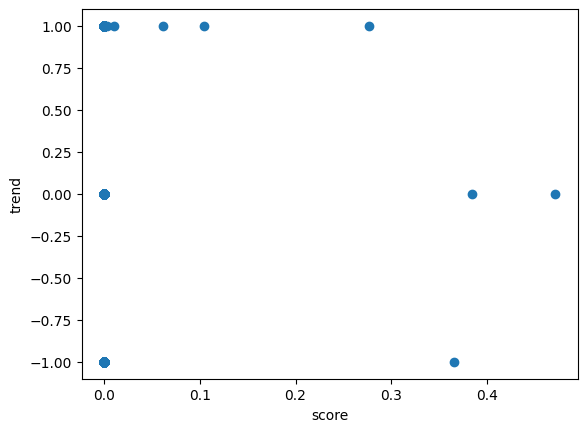

In [59]:
plt.scatter(aapl_df.overall_sentiment_score,aapl_df.trend)
plt.xlabel('score')
plt.ylabel('trend')

<Axes: xlabel='time_published'>

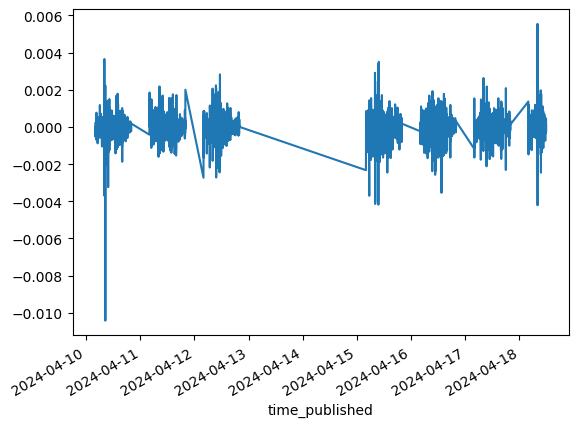

In [56]:
aapl_df.ret.plot()